# BAN6800 — BA-12: Risk Ranking Logic

**Selected model:** Random Forest from BA-09/BA-10  
**Purpose:** Convert model probability outputs into a transparent ranked risk register for downstream dashboarding and human review.

## Proxy boundary
The UCI APS dataset does not contain CGSL vessel/equipment identifiers or CGSL asset-criticality data. The notebook therefore uses a synthetic-looking **proxy observation ID** (`UCI_TEST_#####`) only for ranking. These are not actual CGSL assets.

## Initial demonstration risk rules
- **Critical:** risk score >= 0.50 → Immediate technical review / inspection
- **High:** 0.10 <= risk score < 0.50 → Prioritize technical review and planned inspection
- **Lower:** risk score < 0.10 → Continue monitoring; no automatic intervention

The 0.10 boundary is the BA-10 threshold selected under the UCI proxy cost assumptions. These categories are initial demonstration rules and must be recalibrated with governed CGSL data, asset criticality, operational constraints, and actual costs before production use.

The model remains human-supervised decision support; it does not authorize autonomous maintenance or safety-critical control.


In [1]:
# BA-12 setup

import os
import json
from io import BytesIO

import requests
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
SELECTED_THRESHOLD = 0.10

print("BA-12 libraries loaded successfully.")


BA-12 libraries loaded successfully.


## 1. Load the final BA-07 features and selected BA-10 Random Forest

The final BA-07 representation contains 334 features. The large `.npy` arrays and selected model are stored through Git LFS.


In [7]:
TRAIN_URL = "https://media.githubusercontent.com/media/dvfekorigha-create/BAN6800-cgsl-predictive-maintenance/main/data/processed/X_train_final.npy"
TEST_URL = "https://media.githubusercontent.com/media/dvfekorigha-create/BAN6800-cgsl-predictive-maintenance/main/data/processed/X_test_final.npy"
MODEL_URL = "https://media.githubusercontent.com/media/dvfekorigha-create/BAN6800-cgsl-predictive-maintenance/main/models/random_forest_selected_baseline.joblib"
Y_TEST_URL = "https://raw.githubusercontent.com/dvfekorigha-create/BAN6800-cgsl-predictive-maintenance/main/data/processed/y_test.csv"

def get_bytes(url, label):
    r = requests.get(url, timeout=180)
    r.raise_for_status()
    print(f"{label}: {len(r.content) / 1024**2:.1f} MB")
    return r.content

X_train = np.load(BytesIO(get_bytes(TRAIN_URL, "X_train_final")), allow_pickle=False)
X_test = np.load(BytesIO(get_bytes(TEST_URL, "X_test_final")), allow_pickle=False)
# Load the BA-10 Random Forest model directly from your computer

from google.colab import files
import joblib

uploaded = files.upload()

model_file = "random_forest_selected_baseline.joblib"

if model_file not in uploaded:
    raise FileNotFoundError(
        "Please upload random_forest_selected_baseline.joblib"
    )

rf_final = joblib.load(model_file)

print("Random Forest model loaded successfully.")
print("Model classes:", list(rf_final.classes_))
y_test = pd.read_csv(Y_TEST_URL).squeeze("columns")

assert X_train.shape == (60000, 334)
assert X_test.shape == (16000, 334)
assert len(y_test) == 16000

print("Training:", X_train.shape)
print("Test:", X_test.shape)
print("Model classes:", list(rf_final.classes_))

X_train_final: 152.9 MB
X_test_final: 40.8 MB


Saving random_forest_selected_baseline.joblib to random_forest_selected_baseline.joblib
Random Forest model loaded successfully.
Model classes: ['neg', 'pos']
Training: (60000, 334)
Test: (16000, 334)
Model classes: ['neg', 'pos']


## 2. Generate risk scores and rank observations

Risk score = Random Forest predicted probability of the positive UCI class.

The audit label is retained only for post-hoc verification. It is **not** used to calculate the score, category, priority, or recommendation.


In [8]:
classes = list(rf_final.classes_)
pos_index = classes.index("pos")

risk_score = rf_final.predict_proba(X_test)[:, pos_index]

ranking = pd.DataFrame({
    "Observation_ID": [f"UCI_TEST_{i:05d}" for i in range(1, len(X_test) + 1)],
    "Risk_Score": np.clip(risk_score, 0, 1),
    "Actual_Class_Audit": y_test.to_numpy(),
})

def risk_category(score):
    if score >= 0.50:
        return "Critical"
    if score >= SELECTED_THRESHOLD:
        return "High"
    return "Lower"

ranking["Risk_Category"] = ranking["Risk_Score"].map(risk_category)

ranking["Recommended_Action"] = ranking["Risk_Category"].map({
    "Critical": "Immediate technical review / inspection",
    "High": "Prioritize technical review and planned inspection",
    "Lower": "Continue monitoring; no automatic intervention",
})

ranking["Priority_Level"] = ranking["Risk_Category"].map({
    "Critical": "P1",
    "High": "P2",
    "Lower": "P3",
})

ranking["Review_Status"] = ranking["Risk_Category"].map({
    "Critical": "Human review required",
    "High": "Human review required",
    "Lower": "Routine monitoring",
})

ranking = ranking.sort_values(
    ["Risk_Score", "Observation_ID"],
    ascending=[False, True]
).reset_index(drop=True)

ranking["Risk_Rank"] = np.arange(1, len(ranking) + 1)

print("Risk ranking created.")
display(ranking.head(20))


Risk ranking created.


,Observation_ID,Risk_Score,Actual_Class_Audit,Risk_Category,Recommended_Action,Priority_Level,Review_Status,Risk_Rank
0,UCI_TEST_06259,0.980000,pos,Critical,Immediate technical review / inspection,P1,Human review required,1
1,UCI_TEST_03582,0.979276,pos,Critical,Immediate technical review / inspection,P1,Human review required,2
2,UCI_TEST_09397,0.978807,pos,Critical,Immediate technical review / inspection,P1,Human review required,3
3,UCI_TEST_13605,0.973027,pos,Critical,Immediate technical review / inspection,P1,Human review required,4
4,UCI_TEST_03894,0.973007,pos,Critical,Immediate technical review / inspection,P1,Human review required,5
5,UCI_TEST_15417,0.972084,pos,Critical,Immediate technical review / inspection,P1,Human review required,6
6,UCI_TEST_04406,0.971745,pos,Critical,Immediate technical review / inspection,P1,Human review required,7
7,UCI_TEST_13330,0.966078,pos,Critical,Immediate technical review / inspection,P1,Human review required,8
8,UCI_TEST_13249,0.965482,pos,Critical,Immediate technical review / inspection,P1,Human review required,9
9,UCI_TEST_04368,0.959056,pos,Critical,Immediate technical review / inspection,P1,Human review required,10


In [9]:
# Risk category summary

risk_summary = (
    ranking.groupby("Risk_Category")
    .agg(
        Observation_Count=("Observation_ID", "count"),
        Mean_Risk_Score=("Risk_Score", "mean"),
        Maximum_Risk_Score=("Risk_Score", "max"),
    )
    .reset_index()
)

risk_summary["Percentage"] = (
    risk_summary["Observation_Count"] / len(ranking) * 100
)

order = pd.CategoricalDtype(["Critical", "High", "Lower"], ordered=True)
risk_summary["Risk_Category"] = risk_summary["Risk_Category"].astype(order)
risk_summary = risk_summary.sort_values("Risk_Category")

display(risk_summary)


,Risk_Category,Observation_Count,Mean_Risk_Score,Maximum_Risk_Score,Percentage
0,Critical,271,0.737157,0.980000,1.69375
1,High,382,0.252786,0.496781,2.38750
2,Lower,15347,0.002846,0.099965,95.91875


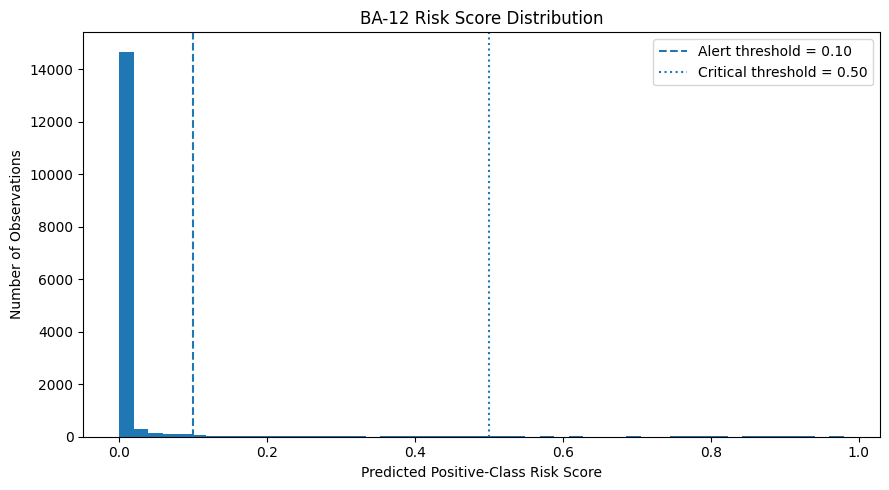

In [10]:
# Visualize risk-score distribution

plt.figure(figsize=(9, 5))
plt.hist(ranking["Risk_Score"], bins=50)
plt.axvline(SELECTED_THRESHOLD, linestyle="--", label="Alert threshold = 0.10")
plt.axvline(0.50, linestyle=":", label="Critical threshold = 0.50")
plt.xlabel("Predicted Positive-Class Risk Score")
plt.ylabel("Number of Observations")
plt.title("BA-12 Risk Score Distribution")
plt.legend()
plt.tight_layout()
plt.savefig("BA-12_risk_score_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


## 3. Dashboard-ready risk output

The dashboard-ready file excludes the actual target label so the risk-ranking layer remains clearly separated from post-hoc audit information.


In [11]:
dashboard_ready = ranking[
    [
        "Risk_Rank",
        "Observation_ID",
        "Risk_Score",
        "Risk_Category",
        "Priority_Level",
        "Recommended_Action",
        "Review_Status",
    ]
].copy()

display(dashboard_ready.head(20))


,Risk_Rank,Observation_ID,Risk_Score,Risk_Category,Priority_Level,Recommended_Action,Review_Status
0,1,UCI_TEST_06259,0.980000,Critical,P1,Immediate technical review / inspection,Human review required
1,2,UCI_TEST_03582,0.979276,Critical,P1,Immediate technical review / inspection,Human review required
2,3,UCI_TEST_09397,0.978807,Critical,P1,Immediate technical review / inspection,Human review required
3,4,UCI_TEST_13605,0.973027,Critical,P1,Immediate technical review / inspection,Human review required
4,5,UCI_TEST_03894,0.973007,Critical,P1,Immediate technical review / inspection,Human review required
5,6,UCI_TEST_15417,0.972084,Critical,P1,Immediate technical review / inspection,Human review required
6,7,UCI_TEST_04406,0.971745,Critical,P1,Immediate technical review / inspection,Human review required
7,8,UCI_TEST_13330,0.966078,Critical,P1,Immediate technical review / inspection,Human review required
8,9,UCI_TEST_13249,0.965482,Critical,P1,Immediate technical review / inspection,Human review required
9,10,UCI_TEST_04368,0.959056,Critical,P1,Immediate technical review / inspection,Human review required


In [12]:
# Save BA-12 artifacts

ranking.drop(columns=["Actual_Class_Audit"]).to_csv(
    "BA-12_risk_ranked_observations.csv", index=False
)

dashboard_ready.to_csv(
    "BA-12_dashboard_risk_dataset.csv", index=False
)

risk_summary.to_csv(
    "BA-12_risk_category_summary.csv", index=False
)

ranking.to_csv(
    "BA-12_risk_ranking_audit_with_labels.csv", index=False
)

rules = {
    "selected_model": "Random Forest",
    "risk_score": "Predicted probability of positive UCI class",
    "alert_threshold": SELECTED_THRESHOLD,
    "critical_threshold": 0.50,
    "rules": {
        "Critical": "score >= 0.50 -> Immediate technical review / inspection",
        "High": "0.10 <= score < 0.50 -> Prioritize technical review and planned inspection",
        "Lower": "score < 0.10 -> Continue monitoring; no automatic intervention",
    },
    "proxy_observation_ids": True,
    "human_oversight": True,
    "autonomous_control": False,
}

with open("BA-12_risk_rules.json", "w", encoding="utf-8") as f:
    json.dump(rules, f, indent=2)

with open("BA-12_risk_rules.md", "w", encoding="utf-8") as f:
    f.write(
        "# BA-12 Risk Ranking Business Rules\n\n"
        "Critical: risk score >= 0.50 -> Immediate technical review / inspection.\n\n"
        "High: 0.10 <= risk score < 0.50 -> Prioritize technical review and planned inspection.\n\n"
        "Lower: risk score < 0.10 -> Continue monitoring; no automatic intervention.\n\n"
        "Risk rank is descending model score; rank 1 is highest.\n\n"
        "UCI_TEST_##### identifiers are proxy observation IDs, not CGSL asset IDs.\n\n"
        "Rules are initial demonstration rules and require production recalibration with governed CGSL data and actual costs.\n"
    )

print("BA-12 artifacts saved.")


BA-12 artifacts saved.


## BA-12 conclusion

The selected Random Forest has been converted into a transparent risk-ranking layer using model probability, explicit risk bands, priority levels, and human-review actions.

The ranking is suitable for downstream Power BI use. Because the source data are a public truck-domain proxy and lack CGSL asset criticality and operational context, the risk bands are demonstration rules rather than validated production thresholds.


In [13]:
# Final artifact inventory and downloadable bundle

from google.colab import files
import zipfile

artifact_files = [
    "BA-12_risk_ranked_observations.csv",
    "BA-12_dashboard_risk_dataset.csv",
    "BA-12_risk_category_summary.csv",
    "BA-12_risk_ranking_audit_with_labels.csv",
    "BA-12_risk_score_distribution.png",
    "BA-12_risk_rules.json",
    "BA-12_risk_rules.md",
]

for name in artifact_files:
    print(f"{name}: {'READY' if os.path.exists(name) else 'MISSING'}")

missing = [name for name in artifact_files if not os.path.exists(name)]
if missing:
    raise FileNotFoundError(f"Missing artifacts: {missing}")

with zipfile.ZipFile("BA-12_artifacts.zip", "w", zipfile.ZIP_DEFLATED) as z:
    for name in artifact_files:
        z.write(name)

print("Created BA-12_artifacts.zip")
files.download("BA-12_artifacts.zip")


BA-12_risk_ranked_observations.csv: READY
BA-12_dashboard_risk_dataset.csv: READY
BA-12_risk_category_summary.csv: READY
BA-12_risk_ranking_audit_with_labels.csv: READY
BA-12_risk_score_distribution.png: READY
BA-12_risk_rules.json: READY
BA-12_risk_rules.md: READY
Created BA-12_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>